In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

def plot_data(filepath):
    xs, ys, ppls, costs = [], [], [], []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            xs.append(int(parts[0]))
            ys.append(int(parts[1]))
            ppls.append(float(parts[2]))
            costs.append(int(parts[3]))

    # Sort by y first, then x
    entries = list(zip(ys, xs, ppls, costs))
    entries.sort(key=lambda e: (e[0], e[1]))

    sorted_ys = [e[0] for e in entries]
    sorted_xs = [e[1] for e in entries]
    sorted_ppls = [e[2] for e in entries]
    sorted_costs = [e[3] for e in entries]

    labels = [f"x={x}, y={y}" for y, x in zip(sorted_ys, sorted_xs)]
    positions = np.arange(len(labels))

    # Green-to-red colormap based on cost
    unique_costs = sorted(set(sorted_costs))
    cost_min, cost_max = min(unique_costs), max(unique_costs)
    cmap = mcolors.LinearSegmentedColormap.from_list("green_red", ["green", "red"])
    norm = mcolors.Normalize(vmin=cost_min, vmax=cost_max)

    # Group indices by (y, cost)
    groups = {}
    for i, (y, x, ppl, cost) in enumerate(zip(sorted_ys, sorted_xs, sorted_ppls, sorted_costs)):
        key = (y, cost)
        groups.setdefault(key, []).append(i)

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.45), 6))

    # Track which costs have been labeled already (for legend)
    labeled_costs = set()

    for (y, cost), idxs in sorted(groups.items()):
        color = cmap(norm(cost))
        label = f"cost={cost}" if cost not in labeled_costs else None
        labeled_costs.add(cost)
        ax.plot([positions[i] for i in idxs],
                [sorted_ppls[i] for i in idxs],
                color=color, marker='o', markersize=5, linewidth=1.5,
                label=label, zorder=3)

    # Vertical separators between y groups
    prev_y = sorted_ys[0]
    for i, y in enumerate(sorted_ys):
        if y != prev_y:
            ax.axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
            prev_y = y

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('ppl')
    ax.set_xlabel('(x, y)')
    ax.grid(axis='y', alpha=0.3)

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('cost')

    fig.tight_layout()
    plt.savefig('plot.png', dpi=150)
    plt.show()


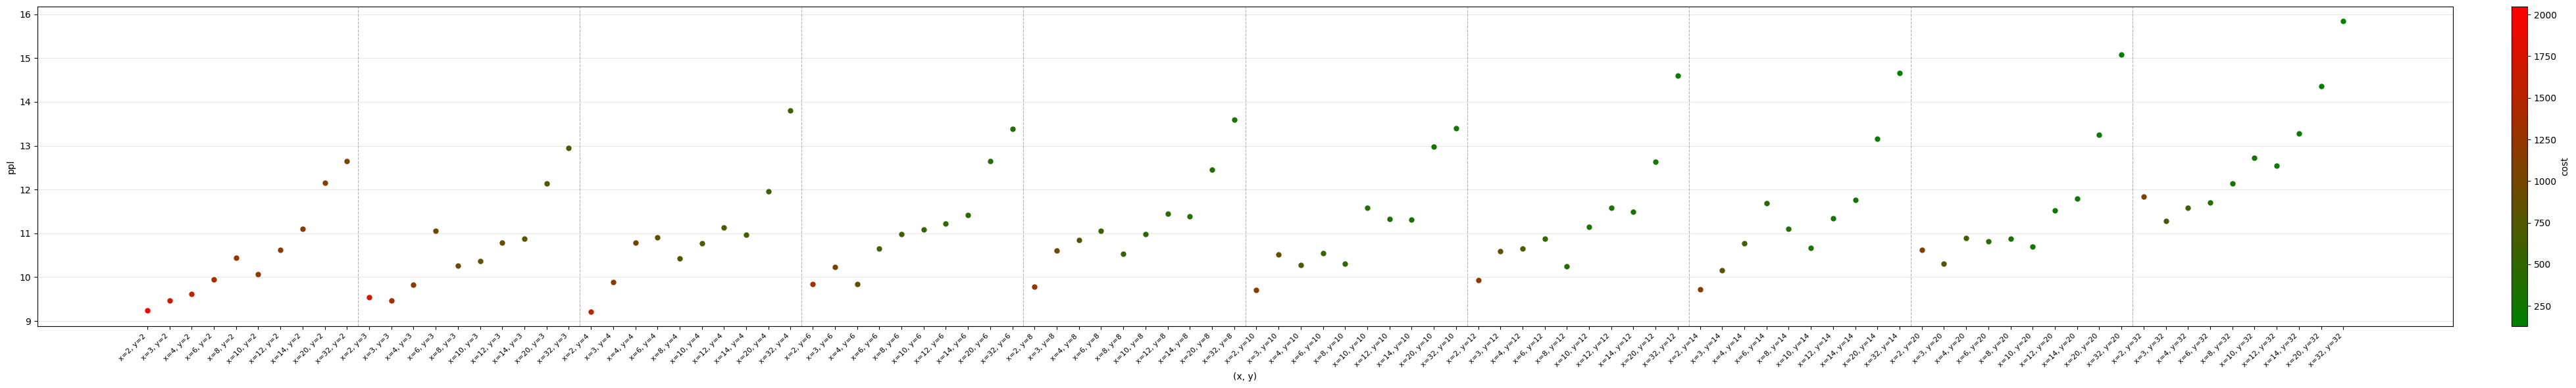

In [ ]:

if __name__ == '__main__':
    plot_data('data.csv')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

def plot_data(filepath):
    xs, ys, ppls, costs = [], [], [], []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            xs.append(int(parts[1]))
            ys.append(int(parts[0]))
            ppls.append(float(parts[2]))
            costs.append(int(parts[3]))

    # Sort by y first, then x
    entries = list(zip(ys, xs, ppls, costs))
    entries.sort(key=lambda e: (e[0], e[1]))

    sorted_ys = [e[0] for e in entries]
    sorted_xs = [e[1] for e in entries]
    sorted_ppls = [e[2] for e in entries]
    sorted_costs = [e[3] for e in entries]

    labels = [f"x={x}, y={y}" for y, x in zip(sorted_ys, sorted_xs)]
    positions = np.arange(len(labels))

    # Green-to-red colormap based on cost
    unique_costs = sorted(set(sorted_costs))
    cost_min, cost_max = min(unique_costs), max(unique_costs)
    cmap = mcolors.LinearSegmentedColormap.from_list("green_red", ["green", "red"])
    norm = mcolors.Normalize(vmin=cost_min, vmax=cost_max)

    # Group indices by (y, cost)
    groups = {}
    for i, (y, x, ppl, cost) in enumerate(zip(sorted_ys, sorted_xs, sorted_ppls, sorted_costs)):
        key = (y, cost)
        groups.setdefault(key, []).append(i)

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.45), 6))

    # Track which costs have been labeled already (for legend)
    labeled_costs = set()

    for (y, cost), idxs in sorted(groups.items()):
        color = cmap(norm(cost))
        label = f"cost={cost}" if cost not in labeled_costs else None
        labeled_costs.add(cost)
        ax.plot([positions[i] for i in idxs],
                [sorted_ppls[i] for i in idxs],
                color=color, marker='o', markersize=5, linewidth=1.5,
                label=label, zorder=3)

    # Vertical separators between y groups
    prev_y = sorted_ys[0]
    for i, y in enumerate(sorted_ys):
        if y != prev_y:
            ax.axvline(x=i - 0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
            prev_y = y

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('ppl')
    ax.set_xlabel('(x, y)')
    ax.grid(axis='y', alpha=0.3)

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)
    cbar.set_label('cost')

    fig.tight_layout()
    plt.savefig('plot.png', dpi=150)
    plt.show()
